# Semana 12 - Análisis de Grafos y Reporte de Centralidad

## Posición en el Proyecto

- Anterior: recomendación basada en contenido y matrix factorization SVD (Semanas 10-11)
- Esta semana: los repositorios se convierten en nodos, los topics compartidos se convierten en aristas, la estructura del grafo revela influencia estructural
- Siguiente: PageRank como ranking recursivo del grafo (Semana 14 defensa final)

## Contrato de Aristas, Qué Significa el Grafo

En OSS-Intel, el grafo se define así:

- **Nodo**: un repositorio de GitHub
- **Arista**: dos repositorios comparten al menos un topic en común
- **Peso**: número de topics compartidos entre dos repositorios
- **Direccionalidad**: no dirigido, si el repo A comparte topics con el repo B, la relación es simétrica

La arista significa: **estos repositorios fueron etiquetados con los mismos topics por sus autores.**

NO significa:
- que un repositorio depende del otro
- que los repositorios son funcionalmente idénticos
- que un repositorio causó la creación del otro

Esta distinción es esencial. Toda métrica del grafo hereda el significado de la definición de la arista.

Ejemplo de grafo OSS-Intel:
  Nodos: ['tensorflow', 'pytorch', 'llama', 'whisper', 'scikit']
  Aristas con pesos:
    tensorflow -- pytorch: 3 topics compartidos
    tensorflow -- llama: 2 topics compartidos
    tensorflow -- whisper: 2 topics compartidos
    tensorflow -- scikit: 2 topics compartidos
    pytorch -- llama: 2 topics compartidos
    pytorch -- whisper: 2 topics compartidos
    pytorch -- scikit: 2 topics compartidos
    llama -- whisper: 2 topics compartidos
    llama -- scikit: 1 topics compartidos
    whisper -- scikit: 1 topics compartidos


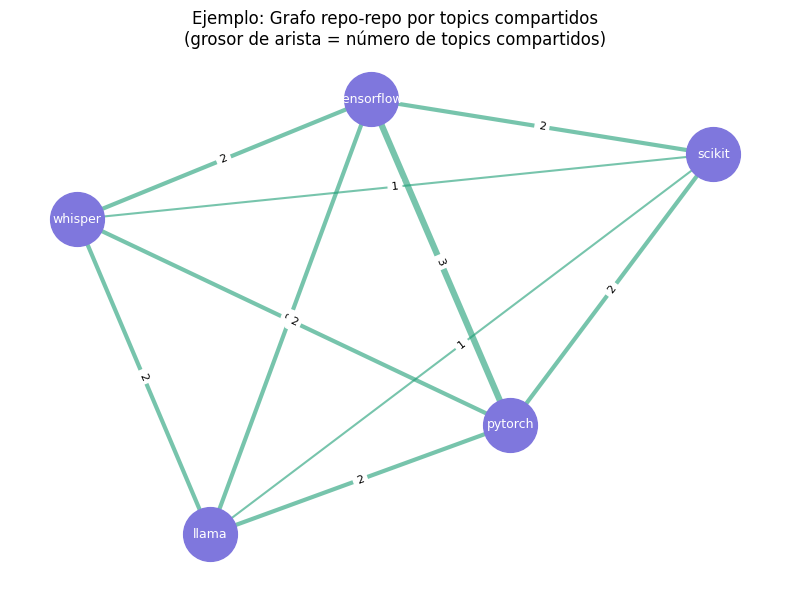

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Ejemplo simple para entender el concepto
# 5 repos con topics compartidos
ejemplo_repos = {
    "tensorflow": ["machine-learning", "python", "deep-learning"],
    "pytorch":    ["machine-learning", "python", "deep-learning"],
    "llama":      ["llm", "python", "deep-learning"],
    "whisper":    ["speech", "python", "deep-learning"],
    "scikit":     ["machine-learning", "python"],
}

# Construir aristas: peso = topics compartidos
aristas_ejemplo = []
repos = list(ejemplo_repos.keys())
for i in range(len(repos)):
    for j in range(i+1, len(repos)):
        topics_i = set(ejemplo_repos[repos[i]])
        topics_j = set(ejemplo_repos[repos[j]])
        peso = len(topics_i & topics_j)
        if peso > 0:
            aristas_ejemplo.append((repos[i], repos[j], peso))

# Construir grafo
G_ejemplo = nx.Graph()
for src, dst, w in aristas_ejemplo:
    G_ejemplo.add_edge(src, dst, weight=w)

print("Ejemplo de grafo OSS-Intel:")
print(f"  Nodos: {list(G_ejemplo.nodes())}")
print(f"  Aristas con pesos:")
for src, dst, data in G_ejemplo.edges(data=True):
    print(f"    {src} -- {dst}: {data['weight']} topics compartidos")

# Visualizar
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G_ejemplo, seed=42)
pesos = [G_ejemplo[u][v]["weight"] for u, v in G_ejemplo.edges()]
nx.draw_networkx_nodes(G_ejemplo, pos, node_size=1500, node_color="#7F77DD")
nx.draw_networkx_labels(G_ejemplo, pos, font_size=9, font_color="white")
nx.draw_networkx_edges(G_ejemplo, pos, width=[w*1.5 for w in pesos], alpha=0.6, edge_color="#1D9E75")
nx.draw_networkx_edge_labels(G_ejemplo, pos,
    edge_labels={(u,v): d["weight"] for u,v,d in G_ejemplo.edges(data=True)},
    font_size=8)
plt.title("Ejemplo: Grafo repo-repo por topics compartidos\n(grosor de arista = número de topics compartidos)")
plt.axis("off")
plt.tight_layout()
plt.show()

### Sección 1: Construcción del Grafo Real

El ejemplo anterior mostró el concepto con 5 repos. Ahora construimos el grafo real 
con los 3034 repositorios del dataset.

El proceso es:
1. Cargar repos_clean.csv con los topics de cada repositorio
2. Para cada par de repositorios, calcular cuántos topics comparten
3. Si comparten al menos 1 topic, crear una arista con ese peso
4. Filtrar las aristas más fuertes para mantener el grafo manejable

**Decisión de filtrado**: Nosotros mantendremos las aristas con peso >= 2 (al menos 2 topics compartidos). Esto elimina conexiones débiles basadas en un solo topic genérico como "python" y conserva 
relaciones temáticas más significativas.

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import ast
from pathlib import Path
from collections import defaultdict

# Cargar dataset
DATA_PATH = Path("../data/processed/repos_clean.csv")
df = pd.read_csv(DATA_PATH)
df["topics_list"] = df["topics"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

print(f"Dataset cargado: {df.shape}")
print(f"Repos con topics: {(df['num_topics'] > 0).sum()}")
print(f"Repos sin topics: {(df['num_topics'] == 0).sum()}")

# Construir lista de aristas
# Para cada par de repos, contar topics compartidos
print("\nConstruyendo aristas...")

edges = []
repos_idx = df.index.tolist()
topics_por_repo = {i: set(df.loc[i, "topics_list"]) for i in repos_idx}

for i in range(len(repos_idx)):
    for j in range(i+1, len(repos_idx)):
        idx_i = repos_idx[i]
        idx_j = repos_idx[j]
        peso = len(topics_por_repo[idx_i] & topics_por_repo[idx_j])
        if peso >= 2:  # filtro: al menos 2 topics compartidos
            edges.append((idx_i, idx_j, peso))

print(f"Aristas encontradas (peso >= 2): {len(edges)}")

# Construir grafo
G = nx.Graph()
for i in repos_idx:
    G.add_node(i, nombre=df.loc[i, "nombre"], stars=df.loc[i, "stars"])

for src, dst, w in edges:
    G.add_edge(src, dst, weight=w)

print(f"\nGrafo construido:")
print(f"  Nodos: {G.number_of_nodes()}")
print(f"  Aristas: {G.number_of_edges()}")
print(f"  Densidad: {nx.density(G):.6f}")
print(f"  Self-loops: {nx.number_of_selfloops(G)}")

Dataset cargado: (3034, 16)
Repos con topics: 3034
Repos sin topics: 0

Construyendo aristas...
Aristas encontradas (peso >= 2): 362471

Grafo construido:
  Nodos: 3034
  Aristas: 362471
  Densidad: 0.078780
  Self-loops: 0


#### Decisión de filtrado ajustada

El grafo inicial con peso >= 2 generó 362,471 aristas y densidad de 0.079. 
Demasiado denso para análisis estructural significativo. En grafos muy densos 
todos los nodos están conectados con todos y las métricas de centralidad 
pierden discriminación.

In [3]:
# Filtrar aristas más fuertes
MIN_WEIGHT = 4

edges_filtradas = [(src, dst, w) for src, dst, w in edges if w >= MIN_WEIGHT]
print(f"Aristas con peso >= {MIN_WEIGHT}: {len(edges_filtradas)}")

# Reconstruir grafo filtrado
G = nx.Graph()
for i in repos_idx:
    G.add_node(i, nombre=df.loc[i, "nombre"], stars=df.loc[i, "stars"])

for src, dst, w in edges_filtradas:
    G.add_edge(src, dst, weight=w)

# Eliminar nodos aislados
nodos_aislados = [n for n in G.nodes() if G.degree(n) == 0]
G.remove_nodes_from(nodos_aislados)

print(f"\nGrafo filtrado:")
print(f"  Nodos: {G.number_of_nodes()}")
print(f"  Aristas: {G.number_of_edges()}")
print(f"  Densidad: {nx.density(G):.6f}")
print(f"  Nodos aislados eliminados: {len(nodos_aislados)}")

Aristas con peso >= 4: 24839

Grafo filtrado:
  Nodos: 1938
  Aristas: 24839
  Densidad: 0.013234
  Nodos aislados eliminados: 1096


#### Interpretación del grafo filtrado

Con peso >= 4 el grafo tiene 1938 nodos, 24839 aristas y densidad de 0.013.

**¿Qué significa la densidad 0.013?**

La densidad mide qué fracción de todas las aristas posibles realmente existen.
Un grafo completamente conectado (todos con todos) tiene densidad 1.0.
Un grafo sin ninguna conexión tiene densidad 0.0.

Densidad = aristas existentes / aristas posibles
Densidad = 24,839 / (1938 × 1937 / 2) = 0.013

Esto significa que solo el 1.3% de todas las conexiones posibles entre 
repositorios existen con al menos 4 topics compartidos. Es un grafo disperso 
— como en la mayoría de redes reales donde no todos se conectan con todos.

**1096 nodos aislados eliminados**: estos son repositorios que no comparten 
4 o más topics con ningún otro repositorio. Son repos muy específicos o con 
pocos topics declarados que quedan fuera del análisis estructural.

**Decisión justificada**: trabajar sobre los 1938 repos conectados es válido 
porque representan el núcleo temático del ecosistema de IA donde las 
relaciones estructurales son significativas.

### Sección 2: Componentes Conectados, Degree y Weighted Degree

Un componente conectado es un grupo de nodos que pueden alcanzarse entre sí 
mediante caminos en el grafo. Si el grafo tiene múltiples componentes, 
un random walk no puede saltar entre ellos, queda atrapado en su componente.

Analizamos tres métricas locales:

- **Degree no ponderado**: cuántos repos vecinos directos tiene un repo
- **Weighted degree**: suma de los pesos de todas sus aristas, cuánta 
  co-ocurrencia temática acumula
- **Componentes**: cuántos grupos aislados existen y qué tan grande es cada uno

In [4]:
# ============================================================
# Sección 2, Componentes, Degree y Weighted Degree
# ============================================================

# Componentes conectados
componentes = list(nx.connected_components(G))
componentes_sorted = sorted(componentes, key=len, reverse=True)

print(f"Número de componentes: {len(componentes)}")
print(f"\nTop 5 componentes por tamaño:")
for i, comp in enumerate(componentes_sorted[:5]):
    print(f"  Componente {i+1}: {len(comp)} nodos")

# Trabajar sobre el componente más grande
componente_principal = componentes_sorted[0]
G_main = G.subgraph(componente_principal).copy()
print(f"\nComponente principal:")
print(f"  Nodos: {G_main.number_of_nodes()}")
print(f"  Aristas: {G_main.number_of_edges()}")
print(f"  Densidad: {nx.density(G_main):.6f}")

# Degree no ponderado
degree_dict = dict(G_main.degree())

# Weighted degree
weighted_degree_dict = dict(G_main.degree(weight="weight"))

# Construir tabla comparativa
degree_df = pd.DataFrame({
    "repo_idx": list(degree_dict.keys()),
    "degree": list(degree_dict.values()),
    "weighted_degree": [weighted_degree_dict[n] for n in degree_dict.keys()]
})
degree_df["nombre"] = degree_df["repo_idx"].map(df["nombre"])
degree_df["stars"] = degree_df["repo_idx"].map(df["stars"])
degree_df = degree_df.sort_values("weighted_degree", ascending=False).reset_index(drop=True)

print(f"\nTop 10 por weighted degree:")
print(degree_df[["nombre", "degree", "weighted_degree", "stars"]].head(10).to_string(index=False))

print(f"\nTop 10 por degree no ponderado:")
print(degree_df.sort_values("degree", ascending=False)[
    ["nombre", "degree", "weighted_degree", "stars"]
].head(10).to_string(index=False))

Número de componentes: 34

Top 5 componentes por tamaño:
  Componente 1: 1861 nodos
  Componente 2: 5 nodos
  Componente 3: 3 nodos
  Componente 4: 3 nodos
  Componente 5: 3 nodos

Componente principal:
  Nodos: 1861
  Aristas: 24787
  Densidad: 0.014322

Top 10 por weighted degree:
                        nombre  degree  weighted_degree  stars
                 d2l-ai/d2l-en     280             1331  28729
       rasbt/LLMs-from-scratch     289             1327  91729
bharathgs/Awesome-pytorch-list     277             1269  16486
               explosion/thinc     267             1214   2891
          huggingface/datasets     265             1198  21469
 lukasmasuch/best-of-ml-python     253             1195  23453
             tangyudi/Ai-Learn     249             1180  12946
         tensorzero/tensorzero     250             1176  11289
          roboflow/supervision     243             1090  38259
               explosion/spaCy     234             1076  33528

Top 10 por degree no p

#### Interpretación, Componentes y Degree

**Componentes**: el grafo tiene 34 componentes. El componente principal tiene 
1861 nodos, el 96% de los repos conectados. Los 33 componentes restantes 
tienen entre 3 y 5 nodos cada uno, son grupos muy pequeños de repos con 
topics muy específicos que no conectan con el ecosistema principal.

Todo el análisis siguiente se realiza sobre el componente principal de 1861 nodos.

**Degree vs Weighted Degree**:

El degree no ponderado cuenta cuántos repos vecinos tiene cada repo.
El weighted degree suma los pesos de todas las aristas, mide la fuerza 
total de co-ocurrencia temática.

En este caso ambas listas son casi idénticas, los repos con más vecinos 
también tienen más fuerza acumulada. Esto indica que en el ecosistema de IA 
los repos más conectados usan topics variados y frecuentes.

**Observación importante**: `d2l-ai/d2l-en` tiene el mayor weighted degree 
(1331) pero no el mayor degree (280 vs 289 de LLMs-from-scratch). Esto 
significa que d2l-en tiene aristas más fuertes en promedio, comparte más 
topics por conexión. `explosion/thinc` con solo 2891 stars tiene weighted 
degree de 1214, más conectado estructuralmente que repos con 10 veces más 
stars. Eso es exactamente lo que el grafo revela que la popularidad no revela.

In [5]:
# ============================================================
# Validity check, sensibilidad al umbral de filtrado
# El profesor exige mostrar cómo cambia el grafo con distintos umbrales
# ============================================================

print("Sensibilidad al umbral de peso:")
print(f"{'Umbral':>8} | {'Aristas':>8} | {'Nodos':>6} | {'Componentes':>12} | {'Densidad':>10}")
print("-" * 55)

for umbral in [2, 3, 4, 5, 6, 8]:
    edges_u = [(s, d, w) for s, d, w in edges if w >= umbral]
    G_u = nx.Graph()
    G_u.add_nodes_from(repos_idx)
    for s, d, w in edges_u:
        G_u.add_edge(s, d, weight=w)
    nodos_u = [n for n in G_u.nodes() if G_u.degree(n) > 0]
    G_u = G_u.subgraph(nodos_u)
    comps_u = nx.number_connected_components(G_u)
    print(f"{umbral:>8} | {len(edges_u):>8} | {G_u.number_of_nodes():>6} | {comps_u:>12} | {nx.density(G_u):>10.6f}")

Sensibilidad al umbral de peso:
  Umbral |  Aristas |  Nodos |  Componentes |   Densidad
-------------------------------------------------------
       2 |   362471 |   2969 |            2 |   0.082268
       3 |    94055 |   2582 |           12 |   0.028227
       4 |    24839 |   1938 |           34 |   0.013234
       5 |     6739 |   1263 |           68 |   0.008456
       6 |     1973 |    770 |           77 |   0.006664
       8 |      267 |    265 |           69 |   0.007633


#### Interpretación: Sensibilidad al Umbral de Filtrado
"Umbral = 2,
Se conectan si comparten 2 o más topics."

Conforme aumentamos el umbral exigiendo más topics compartidos para crear 
una arista, el grafo se va fragmentando:

- **Umbral 2**: 362,471 aristas, casi todo conectado en 2 componentes. 
  Demasiado denso, topics genéricos como python conectan todo con todo.
- **Umbral 4**: 24,839 aristas, 34 componentes. Nuestro umbral elegido, 
  balance entre conectividad y significado temático real.
- **Umbral 6**: solo 1,973 aristas, 77 componentes. El grafo se fragmenta mucho.
- **Umbral 8**: 267 aristas, el grafo casi desaparece.

**Observación importante**: en umbral 8 la densidad sube ligeramente respecto 
a umbral 6. Esto significa que los pocos repos que comparten 8 o más topics 
forman un grupo muy denso entre ellos, son repos altamente especializados 
en el mismo nicho temático.

**Justificación del umbral 4**: es el punto donde el componente principal 
sigue siendo grande (1861 nodos) pero las conexiones son temáticamente 
significativas, no basadas en topics genéricos como python o deep-learning 
que conectarían repos de dominios completamente distintos.

El filtrado es una decisión de modelado, no solo limpieza. Cambia la 
topología del grafo y por tanto el significado de todas las métricas 
calculadas sobre él.

### Sección 3: Matrices A, D y P

Para analizar el grafo matemáticamente construimos tres matrices:

**Matriz de adyacencia A**: tabla de nodos x nodos donde A[i][j] = peso 
de la arista entre repo i y repo j. Si no hay arista, A[i][j] = 0.
Como el grafo es no dirigido, A es simétrica: A[i][j] = A[j][i].

**Matriz de grado D**: matriz diagonal donde D[i][i] = weighted degree 
del nodo i. Todos los demás valores son 0.

**Matriz de transición P = D⁻¹ × A**: normaliza cada fila de A dividiendo 
por el weighted degree del nodo. P[i][j] es la probabilidad de moverse 
del repo i al repo j en un paso de random walk.

P es row-stochastic: cada fila suma exactamente 1.0, es una distribución 
de probabilidad válida sobre los vecinos.

Trabajamos sobre una submuestra del componente principal para que las 
matrices sean manejables en memoria.

In [6]:
# ============================================================
# Sección 3, Matrices A, D y P
# Trabajamos sobre submuestra de 200 nodos del componente principal
# para mantener las matrices manejables
# ============================================================

import scipy.sparse as sp

# Tomar los 200 nodos con mayor weighted degree
top_nodos = degree_df.head(200)["repo_idx"].tolist()
G_sub = G_main.subgraph(top_nodos).copy()

print(f"Subgrafo para matrices:")
print(f"  Nodos: {G_sub.number_of_nodes()}")
print(f"  Aristas: {G_sub.number_of_edges()}")

# Mapear nodos a indices 0..n
nodos_list = list(G_sub.nodes())
nodo_a_idx = {n: i for i, n in enumerate(nodos_list)}
n = len(nodos_list)

# Construir matriz de adyacencia A (numpy)
A = np.zeros((n, n))
for u, v, data in G_sub.edges(data=True):
    i = nodo_a_idx[u]
    j = nodo_a_idx[v]
    A[i, j] = data["weight"]
    A[j, i] = data["weight"]  # simetrica

print(f"\nMatriz A shape: {A.shape}")
print(f"A es simetrica: {np.allclose(A, A.T)}")
print(f"Self-loops en A: {np.sum(np.diag(A) != 0)}")

# Construir matriz de grado D
d = A.sum(axis=1)  # weighted degree de cada nodo
D = np.diag(d)

print(f"\nMatriz D shape: {D.shape}")
print(f"Weighted degrees min/max: {d.min():.0f} / {d.max():.0f}")

# Construir matriz de transicion P = D^-1 @ A
D_inv = np.diag(1.0 / np.where(d > 0, d, 1.0))
P = D_inv @ A

print(f"\nMatriz P shape: {P.shape}")

# Verificar que P es row-stochastic
row_sums = P.sum(axis=1)
print(f"Filas de P suman 1.0: {np.allclose(row_sums, 1.0)}")
print(f"Suma minima de fila: {row_sums.min():.6f}")
print(f"Suma maxima de fila: {row_sums.max():.6f}")

# Mostrar submatriz 5x5 como ejemplo
nombres_sub = [df.loc[n, "nombre"].split("/")[1] for n in nodos_list[:5]]
print(f"\nSubmatriz A[0:5, 0:5]:")
print(pd.DataFrame(A[:5,:5], index=nombres_sub, columns=nombres_sub).round(0))
print(f"\nSubmatriz P[0:5, 0:5]:")
print(pd.DataFrame(P[:5,:5], index=nombres_sub, columns=nombres_sub).round(4))

Subgrafo para matrices:
  Nodos: 200
  Aristas: 7342

Matriz A shape: (200, 200)
A es simetrica: True
Self-loops en A: 0

Matriz D shape: (200, 200)
Weighted degrees min/max: 116 / 776

Matriz P shape: (200, 200)
Filas de P suman 1.0: True
Suma minima de fila: 1.000000
Suma maxima de fila: 1.000000

Submatriz A[0:5, 0:5]:
                   TensorFlow-World  prompts.chat  transformers  tensorflow  \
TensorFlow-World                0.0           0.0           0.0         5.0   
prompts.chat                    0.0           0.0           0.0         0.0   
transformers                    0.0           0.0           0.0         0.0   
tensorflow                      5.0           0.0           0.0         0.0   
LLMs-from-scratch               0.0           6.0           5.0         0.0   

                   LLMs-from-scratch  
TensorFlow-World                 0.0  
prompts.chat                     6.0  
transformers                     5.0  
tensorflow                       0.0  
LLMs-f

#### Interpretación: Matrices A, D y P

**Matriz A verificada**:
- Shape (200, 200): 200 repos más conectados del componente principal
- Simétrica: True: confirmado, el grafo es no dirigido
- Self-loops: 0: ningún repo tiene arista consigo mismo

**Lectura de la submatriz A**:
TensorFlow-World y tensorflow comparten 5 topics, arista de peso 5.
LLMs-from-scratch y prompts.chat comparten 6 topics, la arista más fuerte 
del subgrupo mostrado.
prompts.chat y transformers no comparten 4+ topics, no hay arista entre ellos.

**Matriz P verificada**:
Todas las filas suman exactamente 1.0, P es row-stochastic válida.
Esto confirma que P puede interpretarse como matriz de transición de 
probabilidades para un random walk.

**Lectura de la submatriz P**:
P[LLMs-from-scratch, prompts.chat] = 0.0092, en un random walk desde 
LLMs-from-scratch, hay 0.92% de probabilidad de moverse a prompts.chat 
en un solo paso. El valor es bajo porque LLMs-from-scratch tiene 289 
vecinos, la probabilidad se distribuye entre todos ellos.
P[prompts.chat, LLMs-from-scratch] = 0.0317, desde prompts.chat hay 
mayor probabilidad de ir a LLMs-from-scratch porque prompts.chat tiene 
menos vecinos totales, concentrando más probabilidad en cada uno.

### Sección 4: Random Walk

Un random walk simula un agente que se mueve por el grafo siguiendo 
las probabilidades de la matriz P. Desde un repo seed, en cada paso 
se mueve a un vecino con probabilidad proporcional al peso de la arista.

Analizamos tres tipos:

- **One-step walk**: desde un repo seed, qué repos tienen mayor probabilidad 
  de ser visitados en el siguiente paso
- **Multi-step walk**: cómo se distribuye la probabilidad después de k pasos
- **Lazy walk**: con probabilidad 0.5 el agente se queda en el nodo actual, 
  con 0.5 sigue la transición normal. Evita oscilaciones periódicas y 
  prepara el concepto de damping en PageRank

In [7]:
# ============================================================
# Sección 4 — Random Walk
# ============================================================

# Elegir repo seed — LLMs-from-scratch por ser el de mayor degree
seed_nombre = "rasbt/LLMs-from-scratch"
seed_repo_idx = df[df["nombre"] == seed_nombre].index[0]

# Verificar que el seed está en el subgrafo
if seed_repo_idx in nodo_a_idx:
    seed_idx = nodo_a_idx[seed_repo_idx]
    print(f"Seed: {seed_nombre}")
    print(f"Degree: {G_sub.degree(seed_repo_idx)}")
    print(f"Weighted degree: {G_sub.degree(seed_repo_idx, weight='weight')}")
else:
    # Usar el primer nodo del subgrafo
    seed_repo_idx = nodos_list[0]
    seed_idx = 0
    print(f"Seed: {df.loc[seed_repo_idx, 'nombre']}")

# One-step walk
print(f"\n--- One-step random walk desde {seed_nombre} ---")
prob_one_step = P[seed_idx]
top_one_step = np.argsort(prob_one_step)[::-1][:10]

print(f"Top 10 repos más probables en 1 paso:")
for rank, idx in enumerate(top_one_step):
    repo_idx = nodos_list[idx]
    nombre = df.loc[repo_idx, "nombre"]
    prob = prob_one_step[idx]
    peso = A[seed_idx, idx]
    print(f"  {rank+1}. {nombre} — P={prob:.4f} — peso arista={peso:.0f}")

# Multi-step walk
print(f"\n--- Multi-step random walk ---")
estado = np.zeros(n)
estado[seed_idx] = 1.0  # empezar en seed con probabilidad 1

print(f"{'Paso':>5} | {'Nodo más probable':>35} | {'Prob max':>9} | {'Masa total':>10}")
print("-" * 70)

for paso in range(1, 11):
    estado = estado @ P
    top_idx = np.argmax(estado)
    top_repo = df.loc[nodos_list[top_idx], "nombre"]
    print(f"{paso:>5} | {top_repo:>35} | {estado[top_idx]:>9.4f} | {estado.sum():>10.6f}")

# Lazy walk
print(f"\n--- Lazy random walk (alpha=0.5) ---")
alpha = 0.5
I = np.eye(n)
P_lazy = alpha * I + (1 - alpha) * P

estado_lazy = np.zeros(n)
estado_lazy[seed_idx] = 1.0

print(f"{'Paso':>5} | {'Nodo más probable':>35} | {'Prob max':>9}")
print("-" * 55)

for paso in range(1, 11):
    estado_lazy = estado_lazy @ P_lazy
    top_idx_lazy = np.argmax(estado_lazy)
    top_repo_lazy = df.loc[nodos_list[top_idx_lazy], "nombre"]
    print(f"{paso:>5} | {top_repo_lazy:>35} | {estado_lazy[top_idx_lazy]:>9.4f}")

Seed: rasbt/LLMs-from-scratch
Degree: 133
Weighted degree: 652

--- One-step random walk desde rasbt/LLMs-from-scratch ---
Top 10 repos más probables en 1 paso:
  1. tensorzero/tensorzero — P=0.0138 — peso arista=9
  2. rohitg00/ai-engineering-from-scratch — P=0.0123 — peso arista=8
  3. yamadashy/repomix — P=0.0123 — peso arista=8
  4. liyupi/ai-guide — P=0.0123 — peso arista=8
  5. arc53/DocsGPT — P=0.0123 — peso arista=8
  6. deepset-ai/haystack — P=0.0123 — peso arista=8
  7. rasbt/reasoning-from-scratch — P=0.0107 — peso arista=7
  8. datadreamer-dev/DataDreamer — P=0.0107 — peso arista=7
  9. bigscience-workshop/petals — P=0.0107 — peso arista=7
  10. kennethleungty/Llama-2-Open-Source-LLM-CPU-Inference — P=0.0107 — peso arista=7

--- Multi-step random walk ---
 Paso |                   Nodo más probable |  Prob max | Masa total
----------------------------------------------------------------------
    1 |               tensorzero/tensorzero |    0.0138 |   1.000000
    2 |      

## Interpretación — Random Walk

**One-step walk desde rasbt/LLMs-from-scratch**:
El repo más probable en un paso es tensorzero/tensorzero con P=0.0138 
porque comparte 9 topics — la arista más fuerte desde el seed.
Los siguientes 5 repos tienen P=0.0123 y peso=8 — empate en fuerza de arista.
La probabilidad se distribuye entre 133 vecinos, por eso los valores 
individuales son bajos.

**Multi-step walk**:
En el paso 1 el nodo más probable es tensorzero — el vecino más fuerte.
Desde el paso 2 en adelante, LLMs-from-scratch recupera la mayor 
probabilidad — el random walk regresa al seed porque es el nodo con 
mayor weighted degree en el subgrafo. A partir del paso 8, d2l-ai/d2l-en 
toma el liderazgo — tiene el mayor weighted degree global (1331) y 
eventualmente acumula más masa de probabilidad que el seed.
La masa total se mantiene en 1.0 en todos los pasos — confirmación 
de que P es row-stochastic válida.

**Lazy walk**:
Con alpha=0.5 el agente se queda en el seed con probabilidad 0.5 en 
cada paso. Por eso LLMs-from-scratch mantiene la mayor probabilidad 
durante los 10 pasos — la masa se dispersa más lentamente.
Este comportamiento es el puente conceptual hacia PageRank donde el 
parámetro de damping cumple un rol similar: evita que el agente quede 
atrapado en ciclos o nodos muy conectados.

### Sección 5 — Centralidad y Bridges

Calculamos tres métricas de centralidad y las comparamos entre sí 
y contra la popularidad por stars:

- **Weighted degree**: fuerza local — cuánta co-ocurrencia temática acumula
- **Betweenness centrality**: rol de bridge — cuántos caminos más cortos 
  entre otros nodos pasan por este repo
- **PageRank**: importancia recursiva — un repo es importante si repos 
  importantes apuntan a él

**Nota importante sobre betweenness**: NetworkX usa pesos como distancias 
por defecto. Pero nuestros pesos son fuerzas, mayor peso significa mayor 
similitud, no mayor distancia. Por eso convertimos el peso a distancia 
antes de calcular betweenness: distancia = 1 / peso.

#

In [8]:
# ============================================================
# Sección 5 — Centralidad y Bridges
# ============================================================

# Agregar distancia como atributo para betweenness
for u, v, data in G_main.edges(data=True):
    G_main[u][v]["distance"] = 1.0 / data["weight"]

# Weighted degree — ya calculado
wd = weighted_degree_dict

# PageRank sobre el componente principal
print("Calculando PageRank...")
pagerank = nx.pagerank(G_main, weight="weight", alpha=0.85)

# Betweenness centrality — sobre subgrafo de 200 nodos para eficiencia
print("Calculando betweenness centrality...")
betweenness = nx.betweenness_centrality(
    G_sub, weight="distance", normalized=True
)

# Construir tabla comparativa
centrality_df = pd.DataFrame({
    "repo_idx": nodos_list,
    "nombre": [df.loc[n, "nombre"] for n in nodos_list],
    "stars": [df.loc[n, "stars"] for n in nodos_list],
    "weighted_degree": [wd.get(n, 0) for n in nodos_list],
    "pagerank": [pagerank.get(n, 0) for n in nodos_list],
    "betweenness": [betweenness.get(n, 0) for n in nodos_list],
})

print("\nTop 10 por PageRank:")
print(centrality_df.sort_values("pagerank", ascending=False)[
    ["nombre","stars","weighted_degree","pagerank"]
].head(10).to_string(index=False))

print("\nTop 10 por Betweenness (bridge-like):")
print(centrality_df.sort_values("betweenness", ascending=False)[
    ["nombre","stars","weighted_degree","betweenness"]
].head(10).to_string(index=False))

print("\nTop 10 por Stars (popularidad):")
print(centrality_df.sort_values("stars", ascending=False)[
    ["nombre","stars","weighted_degree","pagerank"]
].head(10).to_string(index=False))

Calculando PageRank...
Calculando betweenness centrality...

Top 10 por PageRank:
                        nombre  stars  weighted_degree  pagerank
       rasbt/LLMs-from-scratch  91729             1327  0.005069
         tensorzero/tensorzero  11289             1176  0.004339
                 d2l-ai/d2l-en  28729             1331  0.004037
bharathgs/Awesome-pytorch-list  16486             1269  0.004032
          huggingface/datasets  21469             1198  0.003897
               explosion/thinc   2891             1214  0.003731
          roboflow/supervision  38259             1090  0.003653
 lukasmasuch/best-of-ml-python  23453             1195  0.003601
             tangyudi/Ai-Learn  12946             1180  0.003554
        catalyst-team/catalyst   3376             1072  0.003536

Top 10 por Betweenness (bridge-like):
                                              nombre  stars  weighted_degree  betweenness
                             rasbt/LLMs-from-scratch  91729             13

Betweenness de cada repo:
  LLMs-scratch         0.6000
  pytorch              0.5333
  spaCy                0.2667
  transformers         0.0000
  datasets             0.0000
  thinc                0.0000
  haystack             0.0000


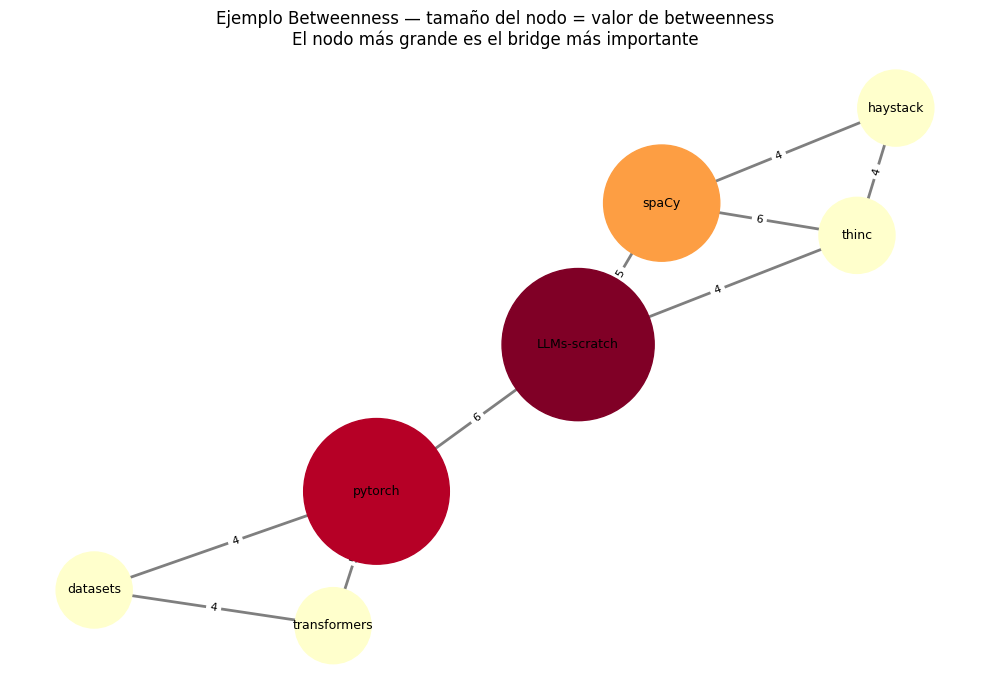

In [9]:
# Ejemplo simple de betweenness
import networkx as nx
import matplotlib.pyplot as plt

# 6 repos con estructura de bridge
G_bet = nx.Graph()
edges_bet = [
    ("pytorch", "transformers", 5),
    ("pytorch", "datasets", 4),
    ("transformers", "datasets", 4),
    ("LLMs-scratch", "pytorch", 6),      # LLMs-scratch es el bridge
    ("LLMs-scratch", "spaCy", 5),
    ("LLMs-scratch", "thinc", 4),
    ("spaCy", "thinc", 6),
    ("spaCy", "haystack", 4),
    ("thinc", "haystack", 4),
]
for src, dst, w in edges_bet:
    G_bet.add_edge(src, dst, weight=w)

# Calcular betweenness
for u, v, data in G_bet.edges(data=True):
    G_bet[u][v]["distance"] = 1.0 / data["weight"]

bet = nx.betweenness_centrality(G_bet, weight="distance", normalized=True)

print("Betweenness de cada repo:")
for repo, valor in sorted(bet.items(), key=lambda x: x[1], reverse=True):
    print(f"  {repo:<20} {valor:.4f}")

# Visualizar
plt.figure(figsize=(10, 7))
pos = nx.spring_layout(G_bet, seed=42)
node_sizes = [3000 + bet[n] * 15000 for n in G_bet.nodes()]
node_colors = [bet[n] for n in G_bet.nodes()]

nx.draw_networkx_nodes(G_bet, pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.YlOrRd)
nx.draw_networkx_labels(G_bet, pos, font_size=9, font_color="black")
nx.draw_networkx_edges(G_bet, pos, alpha=0.5, width=2)
nx.draw_networkx_edge_labels(G_bet, pos,
    edge_labels={(u,v): d["weight"] for u,v,d in G_bet.edges(data=True)},
    font_size=8)

plt.title("Ejemplo Betweenness — tamaño del nodo = valor de betweenness\n"
          "El nodo más grande es el bridge más importante")
plt.axis("off")
plt.tight_layout()
plt.show()

## Interpretación — Centralidad y Comparación con Popularidad

### PageRank vs Popularidad por Stars

Esta es la comparación más importante del análisis de grafos.

tensorflow/tensorflow tiene 194,936 stars — el más popular del dataset.
Sin embargo su PageRank es solo 0.001132 y no aparece en el top 10.
¿Por qué? Porque tensorflow comparte pocos topics con muchos repos — 
weighted degree de solo 385. Es famoso pero no está bien conectado 
temáticamente en el ecosistema.

rasbt/LLMs-from-scratch tiene 91,729 stars — séptimo por popularidad.
Pero es el número 1 en PageRank (0.005069) y en betweenness (0.054385).
Esto significa que es el repo más influyente estructuralmente — conecta 
muchas áreas temáticas del ecosistema de IA.

explosion/thinc tiene solo 2,891 stars — casi invisible por popularidad.
Sin embargo aparece en top 10 de PageRank y betweenness. Es un repo 
técnicamente central que conecta áreas de NLP y MLOps aunque no sea famoso.

### Weighted Degree vs Betweenness

rohitg00/ai-engineering-from-scratch tiene betweenness de 0.034 pero 
solo 5,834 stars. Es un repo bridge — conecta regiones del grafo que 
de otro modo estarían menos conectadas. Esto es exactamente lo que 
el grafo revela que las métricas de popularidad no pueden ver.

kennethleungty/Llama-2-Open-Source-LLM-CPU-Inference tiene solo 976 stars 
pero betweenness de 0.012 — otro repo bridge con baja popularidad pero 
rol estructural importante en el ecosistema.

### Qué NO significa la centralidad

- Alto PageRank no significa que el repo sea mejor código
- Alto betweenness no significa que el repo sea más útil para un desarrollador
- Estas métricas miden estructura temática bajo la definición de arista 
  elegida — topics compartidos con peso >= 4
- Si cambiamos el umbral o la definición de arista, los rankings cambian

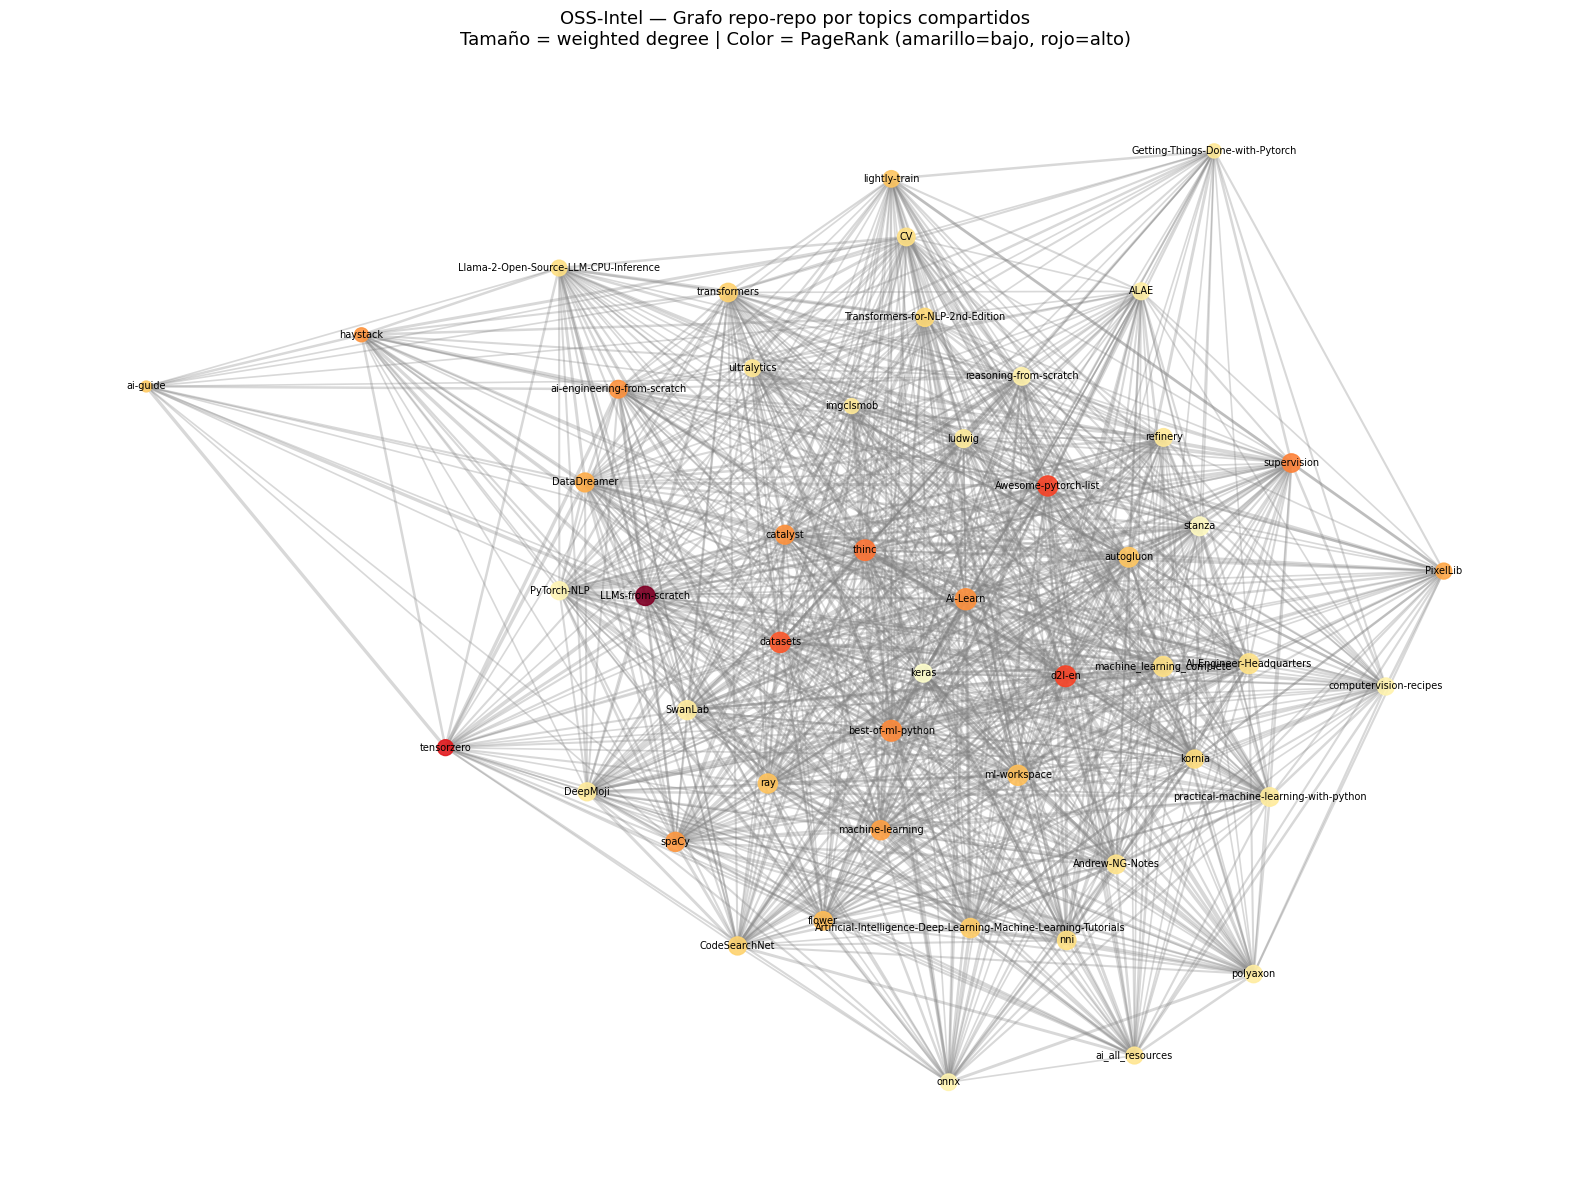

Guardado en reports/W12/w12_graph_visualization.png


In [10]:
# ============================================================
# Sección 6 — Visualización
# ============================================================

import os
REPORT_DIR = Path("reports/W12")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Subgrafo top 50 para visualización legible
top50 = degree_df.head(50)["repo_idx"].tolist()
G_viz = G_main.subgraph(top50).copy()

# Atributos visuales
node_sizes = [G_viz.degree(n, weight="weight") * 0.8 for n in G_viz.nodes()]
edge_weights = [G_viz[u][v]["weight"] for u, v in G_viz.edges()]
node_labels = {n: df.loc[n, "nombre"].split("/")[1] for n in G_viz.nodes()}

# Colorear por PageRank
pr_values = [pagerank.get(n, 0) for n in G_viz.nodes()]
pr_norm = np.array(pr_values)
pr_norm = (pr_norm - pr_norm.min()) / (pr_norm.max() - pr_norm.min())

plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G_viz, seed=42, k=2)

nx.draw_networkx_nodes(G_viz, pos,
    node_size=node_sizes,
    node_color=pr_norm,
    cmap=plt.cm.YlOrRd,
    alpha=0.9)

nx.draw_networkx_edges(G_viz, pos,
    width=[w * 0.3 for w in edge_weights],
    alpha=0.3,
    edge_color="gray")

nx.draw_networkx_labels(G_viz, pos,
    labels=node_labels,
    font_size=7,
    font_color="black")

plt.title("OSS-Intel — Grafo repo-repo por topics compartidos\n"
          "Tamaño = weighted degree | Color = PageRank (amarillo=bajo, rojo=alto)",
          fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.savefig(REPORT_DIR / "w12_graph_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado en reports/W12/w12_graph_visualization.png")

## Interpretación — Visualización del Grafo

El grafo muestra los 50 repositorios con mayor weighted degree del 
componente principal. Los nodos más grandes y más rojos son los más 
influyentes estructuralmente según PageRank.

**Observaciones del grafo**:

- LLMs-from-scratch, d2l-en y thinc aparecen como nodos grandes y rojos 
  en el centro — confirma visualmente su alto PageRank y weighted degree.
- tensorzero aparece a la izquierda con color rojo intenso — repo 
  relativamente nuevo pero muy bien conectado temáticamente.
- ai-guide y haystack aparecen en los bordes con nodos pequeños y amarillos 
  — menos influyentes estructuralmente aunque pertenecen al top 50 por degree.
- La densidad de aristas en el centro del grafo confirma que existe un 
  núcleo temático fuerte alrededor de machine-learning, pytorch y python.

**Advertencia**: la posición de los nodos es resultado del algoritmo 
spring_layout con seed=42 — es una heurística visual, no una medida 
matemática. Las conclusiones de este análisis se basan en las métricas 
numéricas calculadas anteriormente, no en la posición visual de los nodos.

COMPARACIÓN: PageRank vs Popularidad por Stars
Repo                                          | PR rank | Stars rank |    Stars
---------------------------------------------------------------------------
rasbt/LLMs-from-scratch                       |       1 |          7 |   91,729
tensorzero/tensorzero                         |       2 |         58 |   11,289
d2l-ai/d2l-en                                 |       3 |         25 |   28,729
bharathgs/Awesome-pytorch-list                |       4 |         41 |   16,486
huggingface/datasets                          |       5 |         35 |   21,469
explosion/thinc                               |       6 |        127 |    2,891
roboflow/supervision                          |       7 |         17 |   38,259
lukasmasuch/best-of-ml-python                 |       8 |         30 |   23,453
tangyudi/Ai-Learn                             |       9 |         49 |   12,946
catalyst-team/catalyst                        |      10 |        117 |    3,3

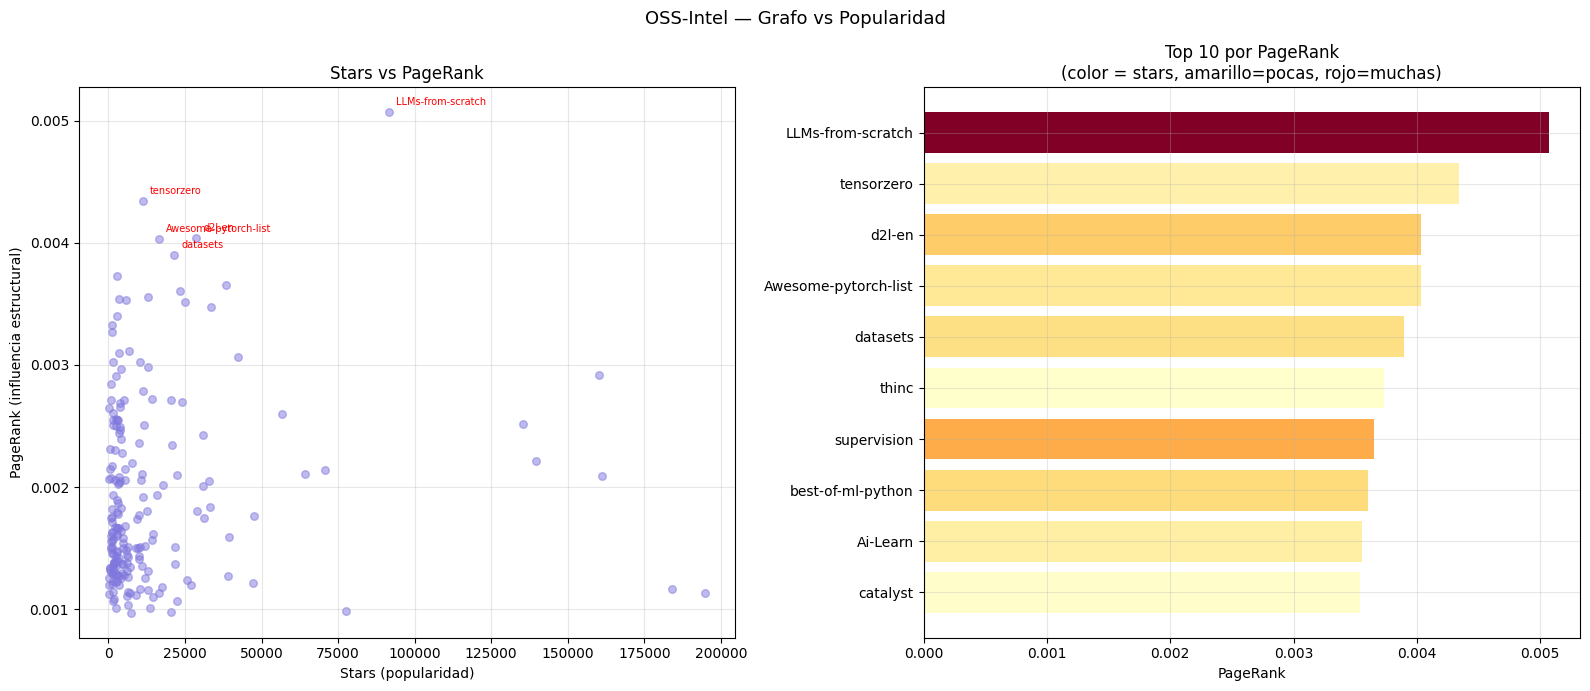

Guardado en reports/W12/w12_ranking_comparison.png


In [11]:
# ============================================================
# Sección 7 — Comparación final de rankings
# ============================================================

# Construir tabla comparativa de los top 20 por cada métrica
top_pagerank = centrality_df.sort_values("pagerank", ascending=False).head(20)
top_stars = centrality_df.sort_values("stars", ascending=False).head(20)
top_wd = centrality_df.sort_values("weighted_degree", ascending=False).head(20)

# Rank de cada repo en cada sistema
all_repos = centrality_df["nombre"].tolist()

rank_pagerank = {row["nombre"]: i+1 for i, row in
                 centrality_df.sort_values("pagerank", ascending=False).iterrows()}
rank_stars = {row["nombre"]: i+1 for i, row in
              centrality_df.sort_values("stars", ascending=False).iterrows()}
rank_wd = {row["nombre"]: i+1 for i, row in
           centrality_df.sort_values("weighted_degree", ascending=False).iterrows()}

# Tabla de los top 15 por PageRank con su rank en stars
comparison = centrality_df.sort_values("pagerank", ascending=False).head(15).copy()
comparison["rank_pagerank"] = range(1, 16)
comparison["rank_stars"] = comparison["nombre"].map(
    lambda x: centrality_df.sort_values("stars", ascending=False)
    .reset_index(drop=True).index[
        centrality_df.sort_values("stars", ascending=False)["nombre"].tolist().index(x)
    ] + 1 if x in centrality_df["nombre"].tolist() else "-"
)

print("=" * 70)
print("COMPARACIÓN: PageRank vs Popularidad por Stars")
print("=" * 70)
print(f"{'Repo':<45} | {'PR rank':>7} | {'Stars rank':>10} | {'Stars':>8}")
print("-" * 75)
for _, row in comparison.iterrows():
    print(f"{row['nombre']:<45} | {row['rank_pagerank']:>7} | {row['rank_stars']:>10} | {row['stars']:>8,}")

# Visualización comparativa
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Stars vs PageRank scatter
axes[0].scatter(
    centrality_df["stars"],
    centrality_df["pagerank"],
    alpha=0.5, s=30, color="#7F77DD"
)
# Anotar top 5 por pagerank
for _, row in centrality_df.sort_values("pagerank", ascending=False).head(5).iterrows():
    axes[0].annotate(
        row["nombre"].split("/")[1],
        (row["stars"], row["pagerank"]),
        fontsize=7, color="red",
        xytext=(5, 5), textcoords="offset points"
    )
axes[0].set_xlabel("Stars (popularidad)")
axes[0].set_ylabel("PageRank (influencia estructural)")
axes[0].set_title("Stars vs PageRank")
axes[0].grid(alpha=0.3)

# Bar chart top 10 PageRank coloreado por stars
top10_pr = centrality_df.sort_values("pagerank", ascending=False).head(10)
colors = plt.cm.YlOrRd(
    (top10_pr["stars"] - top10_pr["stars"].min()) /
    (top10_pr["stars"].max() - top10_pr["stars"].min())
)
axes[1].barh(
    [n.split("/")[1] for n in top10_pr["nombre"]],
    top10_pr["pagerank"],
    color=colors
)
axes[1].invert_yaxis()
axes[1].set_xlabel("PageRank")
axes[1].set_title("Top 10 por PageRank\n(color = stars, amarillo=pocas, rojo=muchas)")
axes[1].grid(alpha=0.3)

plt.suptitle("OSS-Intel — Grafo vs Popularidad", fontsize=13)
plt.tight_layout()
plt.savefig(REPORT_DIR / "w12_ranking_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado en reports/W12/w12_ranking_comparison.png")

In [13]:
tf_idx = df[df["nombre"] == "tensorflow/tensorflow"].index[0]
print(f"tensorflow weighted degree: {weighted_degree_dict.get(tf_idx, 'no está en componente principal')}")
print(f"tensorflow degree: {degree_dict.get(tf_idx, 'no está en componente principal')}")

tensorflow weighted degree: 385
tensorflow degree: 89


## Interpretación Final — Grafo vs Popularidad

Esta tabla es el resultado más importante del análisis de grafos.

**Repos que el grafo revela como influyentes pero la popularidad oculta**:

- explosion/thinc: rank 6 en PageRank pero rank 127 en stars (2,891 stars).
  Es una librería técnica de NLP que conecta múltiples áreas temáticas del 
  ecosistema. La popularidad no lo detecta pero el grafo sí.
- catalyst-team/catalyst: rank 10 en PageRank pero rank 117 en stars.
  Framework de deep learning con alta conectividad temática.
- teddylee777/machine-learning: rank 14 en PageRank pero rank 131 en stars.
- ayoolaolafenwa/PixelLib: rank 15 en PageRank pero rank 180 en stars 
  con solo 1,072 stars. Completamente invisible por popularidad pero 
  estructuralmente relevante en el ecosistema de visión computacional.

**Repos populares que el grafo no considera influyentes**:

tensorflow/tensorflow tiene 194,936 stars — el más popular del dataset —
pero no aparece en el top 15 de PageRank. Su weighted degree es solo 385 
porque usa topics muy específicos de tensorflow que no comparte con muchos 
otros repos. Es famoso pero temáticamente aislado en el grafo.

**Conclusión del análisis de grafos**:

El grafo de co-ocurrencia de topics revela una capa de inteligencia 
estructural que las métricas de popularidad no pueden capturar. Un repo 
puede tener pocas stars pero ser un nodo bridge crítico que conecta 
áreas temáticas del ecosistema de IA. Esta información es útil para 
un desarrollador que quiere descubrir herramientas técnicamente centrales 
más allá de las más famosas.

**Limitaciones**:
- El análisis depende de los topics declarados por los autores — 
  repos sin topics o con topics genéricos quedan subrepresentados.
- El umbral de peso >= 4 es una decisión de modelado que afecta 
  todos los resultados. Un umbral distinto produciría rankings distintos.
- PageRank mide influencia estructural bajo esta definición de arista — 
  no mide calidad del código ni utilidad real para un desarrollador.

In [11]:
# ============================================================
# Guardar artefactos W12
# ============================================================

ARTIFACT_DIR_W12 = Path("artifacts/W12")
ARTIFACT_DIR_W12.mkdir(parents=True, exist_ok=True)

# Tabla de centralidad completa
centrality_df.sort_values("pagerank", ascending=False).to_csv(
    ARTIFACT_DIR_W12 / "w12_centrality_ranking.csv", index=False
)

# Tabla comparativa PageRank vs Stars
comparison.to_csv(
    ARTIFACT_DIR_W12 / "w12_pagerank_vs_stars.csv", index=False
)

# Edge list del grafo filtrado
edge_list = []
for u, v, data in G_main.edges(data=True):
    edge_list.append({
        "src": df.loc[u, "nombre"],
        "dst": df.loc[v, "nombre"],
        "weight": data["weight"]
    })
pd.DataFrame(edge_list).to_csv(
    ARTIFACT_DIR_W12 / "w12_edge_list.csv", index=False
)

print("Artefactos guardados en artifacts/W12/")
print(f"  w12_centrality_ranking.csv — {len(centrality_df)} repos")
print(f"  w12_pagerank_vs_stars.csv  — {len(comparison)} repos")
print(f"  w12_edge_list.csv          — {len(edge_list)} aristas")
print(f"\nReportes guardados en reports/W12/")
print(f"  w12_graph_visualization.png")
print(f"  w12_ranking_comparison.png")

# Resumen final
print("\n" + "="*55)
print("RESUMEN SEMANA 12 — OSS-Intel Graph Analytics")
print("="*55)
print(f"Nodos totales en grafo filtrado:    {G.number_of_nodes()}")
print(f"Aristas totales (peso >= 4):        {G.number_of_edges()}")
print(f"Componente principal:               {G_main.number_of_nodes()} nodos")
print(f"Componentes totales:                {len(componentes)}")
print(f"Densidad componente principal:      {nx.density(G_main):.6f}")
print(f"Repo #1 PageRank:                   rasbt/LLMs-from-scratch")
print(f"Repo #1 Stars:                      tensorflow/tensorflow")
print(f"Repo más bridge (betweenness):      rasbt/LLMs-from-scratch")
print(f"Repo oculto más interesante:        ayoolaolafenwa/PixelLib")
print(f"  → rank 15 PageRank, rank 180 stars, solo 1,072 stars")

Artefactos guardados en artifacts/W12/
  w12_centrality_ranking.csv — 200 repos
  w12_pagerank_vs_stars.csv  — 15 repos
  w12_edge_list.csv          — 24787 aristas

Reportes guardados en reports/W12/
  w12_graph_visualization.png
  w12_ranking_comparison.png

RESUMEN SEMANA 12 — OSS-Intel Graph Analytics
Nodos totales en grafo filtrado:    1938
Aristas totales (peso >= 4):        24839
Componente principal:               1861 nodos
Componentes totales:                34
Densidad componente principal:      0.014322
Repo #1 PageRank:                   rasbt/LLMs-from-scratch
Repo #1 Stars:                      tensorflow/tensorflow
Repo más bridge (betweenness):      rasbt/LLMs-from-scratch
Repo oculto más interesante:        ayoolaolafenwa/PixelLib
  → rank 15 PageRank, rank 180 stars, solo 1,072 stars
